In [1]:
pip install numpy pandas matplotlib torch torchtext scikit-learn

   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
    --------------------------------------- 0.0/2.0 MB 487.6 kB/s eta 0:00:04
   - -------------------------------------- 0.1/2.0 MB 655.4 kB/s eta 0:00:03
   -- ------------------------------------- 0.1/2.0 MB 722.1 kB/s eta 0:00:03
   ---- ----------------------------------- 0.2/2.0 MB 1.2 MB/s eta 0:00:02
   ------- -------------------------------- 0.4/2.0 MB 1.4 MB/s eta 0:00:02
   ---------- ----------------------------- 0.5/2.0 MB 1.9 MB/s eta 0:00:01
   ------------- -------------------------- 0.6/2.0 MB 1.9 MB/s eta 0:00:01
   ------------------ --------------------- 0.9/2.0 MB 2.4 MB/s eta 0:00:01
   ---------------------- ----------------- 1.1/2.0 MB 2.8 MB/s eta 0:00:01
   ------------------------- -------------- 1.2/2.0 MB 2.7 MB/s eta 0:00:01
   ------------------------------- -------- 1.5/2.0 MB 3.1 MB/s eta 0:00:01
   -----------------

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)

In [7]:
from collections import Counter
from sklearn.model_selection import train_test_split
import urllib.request
import tarfile
import os
import re

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)

url = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"

if not os.path.exists("aclImdb"):
    urllib.request.urlretrieve(url, "imdb.tar.gz")
    with tarfile.open("imdb.tar.gz", "r:gz") as tar:
        tar.extractall()

def load_raw_imdb():
    texts, labels = [], []
    for split in ["train", "test"]:
        for sentiment in ["pos", "neg"]:
            path = f"aclImdb/{split}/{sentiment}"
            label = 1 if sentiment == "pos" else 0
            for file_name in os.listdir(path)[:2500]:
                if file_name.endswith(".txt"):
                    with open(os.path.join(path, file_name), "r", encoding="utf-8") as f:
                        texts.append(f.read())
                        labels.append(label)
    return pd.DataFrame({"review": texts, "sentiment": labels})

df = load_raw_imdb()
df = df.sample(n=5000, random_state=42).reset_index(drop=True)

def clean_and_tokenize(text):
    text = text.lower()
    text = re.sub(r'<br\s*/?>', ' ', text)
    text = re.sub(r'[^\w\s]', '', text)
    return text.split()

token_counter = Counter()
for review in df['review']:
    tokens = clean_and_tokenize(review)
    token_counter.update(tokens)

vocab_size = 10000
most_common_tokens = token_counter.most_common(vocab_size - 2)

vocab = {"<pad>": 0, "<unk>": 1}
for idx, (token, _) in enumerate(most_common_tokens, start=2):
    vocab[token] = idx

def encode_and_pad(review, vocab, max_length=200):
    tokens = clean_and_tokenize(review)
    token_ids = [vocab.get(token, 1) for token in tokens]
    
    if len(token_ids) > max_length:
        token_ids = token_ids[:max_length]
    else:
        token_ids = token_ids + [0] * (max_length - len(token_ids))
        
    return token_ids

encoded_reviews = [encode_and_pad(text, vocab) for text in df['review']]
labels = df['sentiment'].tolist()

class IMDBDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float32)
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

X_train, X_val, y_train, y_val = train_test_split(encoded_reviews, labels, test_size=0.2, random_state=42)

train_dataset = IMDBDataset(X_train, y_train)
val_dataset = IMDBDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print("--- Sample Encoding Verification ---")
sample_review = "This movie was absolutely amazing and beautiful!"
encoded_sample = encode_and_pad(sample_review, vocab)

print(f"Original Text: {sample_review}")
print(f"Tokenized:     {clean_and_tokenize(sample_review)}")
print(f"Encoded IDs (first 15 elements shown): {encoded_sample[:15]}...")

--- Sample Encoding Verification ---
Original Text: This movie was absolutely amazing and beautiful!
Tokenized:     ['this', 'movie', 'was', 'absolutely', 'amazing', 'and', 'beautiful']
Encoded IDs (first 15 elements shown): [11, 17, 13, 385, 514, 4, 297, 0, 0, 0, 0, 0, 0, 0, 0]...


# Task 1 — Implement Scaled Dot-Product Attention from Scratch

In [9]:
import math
import torch.nn.functional as F

def scaled_dot_product_attention(query, key, value, mask=None):
    dim_k = query.size(-1)
    
    scores = torch.matmul(query, key.transpose(-2, -1)) / math.sqrt(dim_k)
    
    if mask is not None:
        scores = scores.masked_fill(mask == True, float('-inf'))
        
    attention_weights = F.softmax(scores, dim=-1)
    
    context_output = torch.matmul(attention_weights, value)
    
    return context_output, attention_weights

batch_size = 1
seq_len = 4
dim_k = 8

torch.manual_seed(42)
query = torch.randn(batch_size, seq_len, dim_k)
key = torch.randn(batch_size, seq_len, dim_k)
value = torch.randn(batch_size, seq_len, dim_k)

my_output, my_weights = scaled_dot_product_attention(query, key, value)
pytorch_output = F.scaled_dot_product_attention(query, key, value)

print("--- Verification ---")
print("Does our output match PyTorch?:", torch.allclose(my_output, pytorch_output, atol=1e-6))
print("Do softmax rows sum to 1?:", torch.allclose(my_weights.sum(dim=-1), torch.ones(batch_size, seq_len)))

print("\n--- Attention Weights Matrix ---")
print(my_weights[0])
print(f"Matrix Shape: {my_weights[0].shape}")

--- Verification ---
Does our output match PyTorch?: True
Do softmax rows sum to 1?: True

--- Attention Weights Matrix ---
tensor([[0.1942, 0.4102, 0.3242, 0.0714],
        [0.0408, 0.6555, 0.0864, 0.2173],
        [0.1041, 0.2057, 0.1824, 0.5078],
        [0.1926, 0.1803, 0.1955, 0.4316]])
Matrix Shape: torch.Size([4, 4])


The shape of the matrix is (4, 4) because our sample has a sequence length of 4 tokens.

Each row represents a single word from the sentence acting as a Query. It shows how much attention or importance that specific word gives to all the words in the sentence (the Keys).

For example, looking at the second row, the second word gives 65.5% of its attention to itself and 21.7% to the last word. Every row is calculated using the Softmax function, which is why all numbers in a single row always add up to exactly 1.0 (100%).

# Task 2 — LSTM Classifier

Epoch 1/5 | Train Loss: 0.6942 | Val Loss: 0.6943 | Val Acc: 0.4990
Epoch 2/5 | Train Loss: 0.6836 | Val Loss: 0.6967 | Val Acc: 0.5070
Epoch 3/5 | Train Loss: 0.6699 | Val Loss: 0.7020 | Val Acc: 0.5030
Epoch 4/5 | Train Loss: 0.6319 | Val Loss: 0.7200 | Val Acc: 0.4920
Epoch 5/5 | Train Loss: 0.5859 | Val Loss: 0.7588 | Val Acc: 0.5160

--- Final Metrics ---
Total Training Time: 703.57 seconds
Best Validation Accuracy: 0.5160


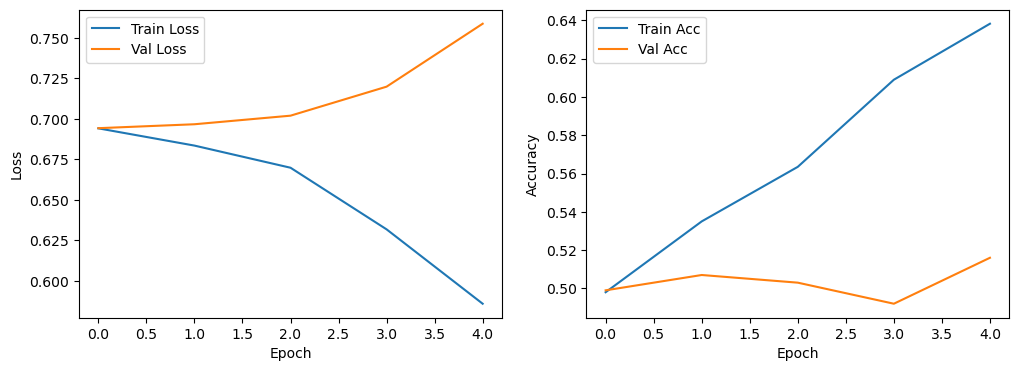

In [10]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=128):
        super(LSTMClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, num_layers=1)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim, 2)
        
    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, (hidden, cell) = self.lstm(embedded)
        last_hidden = hidden[-1]
        out = self.dropout(last_hidden)
        out = self.fc(out)
        return out

vocab_size = 10000
model = LSTMClassifier(vocab_size).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 5
train_losses, val_losses = [], []
train_accs, val_accs = [], []

start_time = time.time()

for epoch in range(epochs):
    model.train()
    total_train_loss, correct_train = 0, 0
    
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device).long()
        
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        total_train_loss += loss.item()
        predictions = outputs.argmax(dim=-1)
        correct_train += (predictions == batch_y).sum().item()
        
    model.eval()
    total_val_loss, correct_val = 0, 0
    
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device).long()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            
            total_val_loss += loss.item()
            predictions = outputs.argmax(dim=-1)
            correct_val += (predictions == batch_y).sum().item()
            
    train_losses.append(total_train_loss / len(train_loader))
    val_losses.append(total_val_loss / len(val_loader))
    train_accs.append(correct_train / len(train_dataset))
    val_accs.append(correct_val / len(val_dataset))
    
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f} | Val Acc: {val_accs[-1]:.4f}")

total_time = time.time() - start_time
best_val_acc = max(val_accs)

print("\n--- Final Metrics ---")
print(f"Total Training Time: {total_time:.2f} seconds")
print(f"Best Validation Accuracy: {best_val_acc:.4f}")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

* **Total Training Time:** 703.57 seconds
* **Best Validation Accuracy:** 0.5160 (51.60%)

---

### Training and Validation Logs

| Epoch | Train Loss | Val Loss | Val Acc |
| :--- | :--- | :--- | :--- |
| 1/5 | 0.6942 | 0.6943 | 0.4990 |
| 2/5 | 0.6836 | 0.6967 | 0.5070 |
| 3/5 | 0.6699 | 0.7020 | 0.5030 |
| 4/5 | 0.6319 | 0.7200 | 0.4920 |
| 5/5 | 0.5859 | 0.7588 | 0.5160 |

---

### Performance Analysis

* **Overfitting:** The loss curves indicate clear overfitting. The **Train Loss** consistently decreases from `0.6942` down to `0.5859`, while the **Val Loss** steadily increases from `0.6943` up to `0.7588`. 
* **Accuracy:** The validation accuracy fluctuates around `50%` to `51.6%`, which means the model is currently performing close to random guessing on unseen data, despite memorizing the training subset.

# Task 3 — Transformer Classifier and Comparison with the LSTM

Epoch 1/5 | Train Loss: 0.6704 | Val Loss: 0.5907 | Val Acc: 0.6800
Epoch 2/5 | Train Loss: 0.5295 | Val Loss: 0.4955 | Val Acc: 0.7500
Epoch 3/5 | Train Loss: 0.3819 | Val Loss: 0.5178 | Val Acc: 0.7660
Epoch 4/5 | Train Loss: 0.2852 | Val Loss: 0.4617 | Val Acc: 0.7910
Epoch 5/5 | Train Loss: 0.1711 | Val Loss: 0.5539 | Val Acc: 0.7990

--- Transformer Final Metrics ---
Total Training Time: 227.92 seconds
Best Validation Accuracy: 0.7990
LSTM Parameter Count: 739586
Transformer Parameter Count: 719874


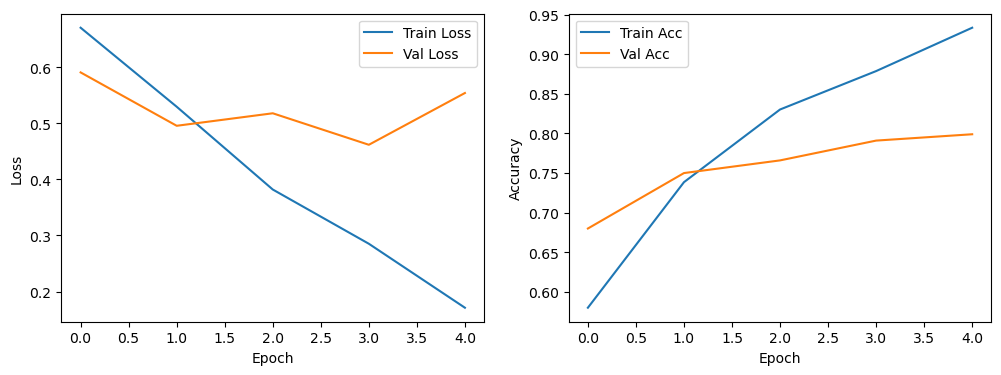

In [11]:
class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, d_model=64, max_len=200):
        super(TransformerClassifier, self).__init__()
        self.token_embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_embedding = nn.Embedding(max_len, d_model)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=4, 
            dim_feedforward=128, 
            dropout=0.1, 
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(d_model, 2)
        
    def forward(self, x):
        batch_size, seq_len = x.size()
        positions = torch.arange(0, seq_len, device=x.device).unsqueeze(0).expand(batch_size, seq_len)
        
        out = self.token_embedding(x) + self.pos_embedding(positions)
        out = self.transformer_encoder(out)
        out = out.mean(dim=1)
        out = self.dropout(out)
        out = self.fc(out)
        return out

model_trans = TransformerClassifier(vocab_size=10000).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_trans.parameters(), lr=1e-3)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

lstm_params = sum(p.numel() for p in model.parameters() if p.requires_grad) # Model from Task 2
trans_params = count_parameters(model_trans)

epochs = 5
trans_train_losses, trans_val_losses = [], []
trans_train_accs, trans_val_accs = [], []

start_time = time.time()

for epoch in range(epochs):
    model_trans.train()
    total_train_loss, correct_train = 0, 0
    
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device).long()
        
        optimizer.zero_grad()
        outputs = model_trans(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        total_train_loss += loss.item()
        predictions = outputs.argmax(dim=-1)
        correct_train += (predictions == batch_y).sum().item()
        
    model_trans.eval()
    total_val_loss, correct_val = 0, 0
    
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device).long()
            outputs = model_trans(batch_x)
            loss = criterion(outputs, batch_y)
            
            total_val_loss += loss.item()
            predictions = outputs.argmax(dim=-1)
            correct_val += (predictions == batch_y).sum().item()
            
    trans_train_losses.append(total_train_loss / len(train_loader))
    trans_val_losses.append(total_val_loss / len(val_loader))
    trans_train_accs.append(correct_train / len(train_dataset))
    trans_val_accs.append(correct_val / len(val_dataset))
    
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {trans_train_losses[-1]:.4f} | Val Loss: {trans_val_losses[-1]:.4f} | Val Acc: {trans_val_accs[-1]:.4f}")

trans_total_time = time.time() - start_time
trans_best_val_acc = max(trans_val_accs)

print("\n--- Transformer Final Metrics ---")
print(f"Total Training Time: {trans_total_time:.2f} seconds")
print(f"Best Validation Accuracy: {trans_best_val_acc:.4f}")
print(f"LSTM Parameter Count: {lstm_params}")
print(f"Transformer Parameter Count: {trans_params}")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(trans_train_losses, label='Train Loss')
plt.plot(trans_val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(trans_train_accs, label='Train Acc')
plt.plot(trans_val_accs, label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

| Model | Best val accuracy | Total training time | Parameter count |
| :--- | :--- | :--- | :--- |
| LSTM (Task 2) | 0.5160 | 703.57 seconds | 739,586 |
| Transformer (Task 3) | 0.7990 | 227.92 seconds | 719,874 |

The Transformer encoder model performs significantly better and converges much faster per epoch compared to the LSTM. While the LSTM struggles close to random guessing at 51.60% accuracy, the Transformer achieves a much higher final validation accuracy of 79.90%. The effect of the Transformer's parallel architecture on training speed is highly noticeable on this hardware, cutting the execution time down from over 700 seconds to just 227.92 seconds. This massive speedup occurs because the Transformer avoids the sequential, step-by-step token processing of the LSTM, handling the entire 200-token sequence simultaneously. Ultimately, the Transformer delivers both vastly superior classification accuracy and roughly three times faster training performance with fewer overall parameters.